# 21 — ST-RAE-Optimal Offset Curve

**Read-only analysis. No model training, no Chemprop, no torch, no submission, no calibration
applied.** A cheap diagnostic that gates whether an interval-aware training objective is worth
pursuing at all.

**Concurrency note**: notebook 20's Chemprop training runs in the background while this executes.
This notebook imports only pandas/numpy/matplotlib/scipy/sklearn and the vendored scorer — no
`torch`, no `chemprop`, nothing CPU-heavy. All outputs go to a new directory,
`outputs/21_strae_offset_curve/` — `outputs/20_residual_exclusion_screen/`,
`outputs/board_solved_calibration/`, `outputs/19_cyp2c9_revert/`, `outputs/11_caruana_prep/`, and
`outputs/05_cv_comparison/` are read-only inputs, never written to. `CLAUDE.md` is not edited —
the intended log entry is written to
`outputs/21_strae_offset_curve/CLAUDE_md_entry_pending.md` for manual insertion once notebook 20
finishes.

## Why this exists

ST-RAE's numerator is a soft-threshold absolute error:

$$e_i = \max(0,\ \text{pred}_i - \text{conf\_high}_i) + \max(0,\ \text{conf\_low}_i - \text{pred}_i)$$

— exactly zero when a prediction falls inside that compound's credible interval. Every model in
this project is trained on MSE against the pIC50 point estimate, then placement is corrected post
hoc with an affine transform. The objective being optimised (MSE against a point) and the metric
being scored (soft-threshold error against an interval) are different functions. Notebook 16
placed CYP2D6 on its solved blind-population centre and the board improved substantially
(ST-RAE 1.1673 → 0.8299). A comparable real entrant on this challenge reports that the placement
maximising R² does *not* minimise ST-RAE, because low-activity compounds carry wide credible
intervals — over-prediction is nearly free, under-prediction is punished. They found their own
ST-RAE optimum by sampling placements against the live board, not deriving it, and named a
credible-interval width model as the missing piece. This project already has the interval widths
(`conf_low`/`conf_high` per compound per isoform) — this notebook derives the optimum locally
instead.

## Part 0 — Setup and provenance

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

from src.vendor.openadmet_eval.config import (
    REGRESSION_CREDIBLE_INTERVALS_LOWER_SUFFIX,
    REGRESSION_CREDIBLE_INTERVALS_UPPER_SUFFIX,
    REGRESSION_ENDPOINTS,
)
from src.vendor.openadmet_eval.custom_scoring_functions import rae_soft_threshold_absolute_error

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"REGRESSION_ENDPOINTS: {REGRESSION_ENDPOINTS}")
print(f"credible interval suffixes: lower={REGRESSION_CREDIBLE_INTERVALS_LOWER_SUFFIX!r}, "
      f"upper={REGRESSION_CREDIBLE_INTERVALS_UPPER_SUFFIX!r}")

CARUANA_PREP = REPO_ROOT / "outputs" / "11_caruana_prep"
CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"

OUT = REPO_ROOT / "outputs" / "21_strae_offset_curve"
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
ENDPOINT_OF = dict(zip(ISOFORMS, REGRESSION_ENDPOINTS))
print(f"\nisoforms: {ISOFORMS}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
scikit-learn: 1.9.0
matplotlib: 3.11.1
REGRESSION_ENDPOINTS: ['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']
credible interval suffixes: lower='_conf_low', upper='_conf_high'

isoforms: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']


### Load pooled OOF predictions, join credible-interval bounds fresh from the curated source

`chemprop_chemeleoninit`'s pooled OOF predictions are read as-is from
`outputs/11_caruana_prep/oof_long_{iso}.csv` (read-only, not recomputed) — this is the full
pooled 5-repeat set (each compound appears once per repeat, from a different held-out fold within
that repeat; e.g. CYP1A2 has 1,412 unique compounds × 5 repeats = 7,060 rows), matching how this
file is used elsewhere in this project (notebook 11b). `conf_low`/`conf_high` are joined **fresh**
from `train_inhibition_curated.csv` on `inchikey` — not reused from the columns already present in
`oof_long_*.csv` — per this task's explicit instruction; the file's own stored bounds are compared
against the fresh join afterward purely as an integrity cross-check.

In [2]:
curated = pd.read_csv(CURATED_PATH)
print(f"loaded {CURATED_PATH.name}: {curated.shape}")

oof = {}
for iso in ISOFORMS:
    endpoint = ENDPOINT_OF[iso]
    lower_col = f"{endpoint}{REGRESSION_CREDIBLE_INTERVALS_LOWER_SUFFIX}"
    upper_col = f"{endpoint}{REGRESSION_CREDIBLE_INTERVALS_UPPER_SUFFIX}"

    raw = pd.read_csv(CARUANA_PREP / f"oof_long_{iso}.csv")
    n_before = len(raw)
    df = raw[["repeat", "fold", "inchikey", "Molecule_Name", "chemprop_chemeleoninit", "y_true",
              "conf_low", "conf_high"]].copy()
    df = df.rename(columns={"conf_low": "conf_low_pooled_file", "conf_high": "conf_high_pooled_file"})

    bounds = curated[["inchikey", lower_col, upper_col]].rename(
        columns={lower_col: "conf_low", upper_col: "conf_high"}
    )
    df = df.merge(bounds, on="inchikey", how="left")
    n_after = len(df)

    print(f"{iso}: oof_long rows before join={n_before}, after={n_after}")
    if n_after != n_before:
        raise ValueError(f"{iso}: join changed row count ({n_before} -> {n_after}) -- stopping.")
    n_null = int(df[["conf_low", "conf_high"]].isna().sum().sum())
    if n_null:
        raise ValueError(f"{iso}: {n_null} null conf_low/conf_high values after join -- stopping.")
    print(f"  nulls in conf_low/conf_high: {n_null}")

    # Integrity cross-check: the freshly-joined bounds should match what oof_long_{iso}.csv
    # already stored under its own conf_low/conf_high columns.
    mismatch = (
        (df["conf_low"] - df["conf_low_pooled_file"]).abs().gt(1e-8)
        | (df["conf_high"] - df["conf_high_pooled_file"]).abs().gt(1e-8)
    ).sum()
    print(f"  mismatches vs. oof_long's own stored bounds: {mismatch}")
    if mismatch:
        raise ValueError(f"{iso}: fresh join disagrees with oof_long's own stored bounds -- stopping.")

    oof[iso] = df.drop(columns=["conf_low_pooled_file", "conf_high_pooled_file"])

print("\nall four isoforms joined, row counts preserved, zero nulls, fresh join matches oof_long's own stored bounds.")

loaded train_inhibition_curated.csv: (4905, 20)
CYP1A2: oof_long rows before join=7060, after=7060
  nulls in conf_low/conf_high: 0
  mismatches vs. oof_long's own stored bounds: 0
CYP2C9: oof_long rows before join=6425, after=6425
  nulls in conf_low/conf_high: 0
  mismatches vs. oof_long's own stored bounds: 0
CYP2D6: oof_long rows before join=7465, after=7465
  nulls in conf_low/conf_high: 0
  mismatches vs. oof_long's own stored bounds: 0
CYP3A4: oof_long rows before join=11675, after=11675
  nulls in conf_low/conf_high: 0
  mismatches vs. oof_long's own stored bounds: 0

all four isoforms joined, row counts preserved, zero nulls, fresh join matches oof_long's own stored bounds.


### Sanity-check the intervals

In [3]:
interval_summary_rows = []
for iso in ISOFORMS:
    df = oof[iso]
    width = df["conf_high"] - df["conf_low"]
    n_violations = int((df["conf_high"] < df["conf_low"]).sum())
    if n_violations:
        print(f"{iso}: {n_violations} rows with conf_high < conf_low -- VIOLATION, reported not dropped:")
        print(df.loc[df["conf_high"] < df["conf_low"], ["Molecule_Name", "inchikey", "conf_low", "conf_high"]].to_string(index=False))

    rho_width_ytrue, p_width_ytrue = spearmanr(width, df["y_true"])
    interval_summary_rows.append({
        "isoform": iso, "n": len(df),
        "width_min": width.min(), "width_median": width.median(), "width_max": width.max(),
        "spearman_width_vs_y_true": rho_width_ytrue, "p_width_vs_y_true": p_width_ytrue,
        "n_conf_high_lt_conf_low": n_violations,
    })

interval_summary = pd.DataFrame(interval_summary_rows)
interval_summary.to_csv(OUT / "interval_summary.csv", index=False)
print(interval_summary.to_string(index=False))

assert (interval_summary["n_conf_high_lt_conf_low"] == 0).all(), "conf_high < conf_low somewhere -- see rows printed above, stopping."
print("\nASSERTION PASSED: conf_high >= conf_low for every row, all four isoforms.")

isoform     n  width_min  width_median  width_max  spearman_width_vs_y_true  p_width_vs_y_true  n_conf_high_lt_conf_low
 CYP1A2  7060   0.102514      0.328330   2.831374                 -0.884741                0.0                        0
 CYP2C9  6425   0.118988      0.525758   2.905461                 -0.899275                0.0                        0
 CYP2D6  7465   0.076737      0.271608   3.134895                 -0.558344                0.0                        0
 CYP3A4 11675   0.068477      0.379150   2.820430                 -0.928344                0.0                        0

ASSERTION PASSED: conf_high >= conf_low for every row, all four isoforms.


**Result: a real, consistent negative correlation between interval width and pIC50 on all four
isoforms** (see `spearman_width_vs_y_true` above — the exact sign/magnitude is read from the table
directly rather than restated here, since it's printed immediately above and this cell would
otherwise risk quoting a stale number). A negative correlation means wider intervals concentrate
at **lower** pIC50, which is the necessary precondition for the claimed asymmetry mechanism
(over-prediction cheap, under-prediction punished) — confirmed quantitatively here, tested
directly (not just assumed) in Part 3 below. No `conf_high < conf_low` violations on any isoform.

## Part 1 — The offset curve

For each isoform independently, a uniform additive offset is swept over `-2.00` to `+2.00` in
steps of `0.01` (401 points, via `np.linspace` for exact endpoints). At each offset, `pred =
chemprop_chemeleoninit + offset`; ST-RAE is computed via the vendored, unmodified
`rae_soft_threshold_absolute_error` (not reimplemented), R² via `sklearn.metrics.r2_score` (the
same function object `ACTIVITY_METRICS` uses elsewhere in this project).

In [4]:
OFFSETS = np.round(np.linspace(-2.0, 2.0, 401), 2)
assert len(OFFSETS) == 401
assert abs(OFFSETS[0] - (-2.0)) < 1e-8 and abs(OFFSETS[-1] - 2.0) < 1e-8
assert np.any(np.isclose(OFFSETS, 0.0)), "0.0 must be exactly on the swept grid"

sweep_rows = []
for iso in ISOFORMS:
    df = oof[iso]
    y_true = df["y_true"].to_numpy()
    y_pred_base = df["chemprop_chemeleoninit"].to_numpy()
    conf_low = df["conf_low"].to_numpy()
    conf_high = df["conf_high"].to_numpy()

    for offset in OFFSETS:
        pred = y_pred_base + offset
        strae = rae_soft_threshold_absolute_error(y_true, pred, y_true_upper=conf_high, y_true_lower=conf_low)
        r2 = r2_score(y_true, pred)
        sweep_rows.append({"isoform": iso, "offset": float(offset), "strae": strae, "r2": r2})

offset_curve = pd.DataFrame(sweep_rows)
offset_curve.to_csv(OUT / "offset_curve.csv", index=False)
print(f"saved {OUT / 'offset_curve.csv'} ({len(offset_curve)} rows)")
print(offset_curve.groupby("isoform").size())

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/21_strae_offset_curve/offset_curve.csv (1604 rows)
isoform
CYP1A2    401
CYP2C9    401
CYP2D6    401
CYP3A4    401
dtype: int64


### Integrity check: Spearman must be invariant under an additive offset

Ordering is untouched by adding a constant to every prediction — Spearman is computed at three
offsets per isoform and asserted not to move. If it moved, the bug would be in this notebook's
pipeline, not in the chemistry.

In [5]:
CHECK_OFFSETS = [-2.0, 0.0, 2.0]
for iso in ISOFORMS:
    df = oof[iso]
    y_true = df["y_true"].to_numpy()
    y_pred_base = df["chemprop_chemeleoninit"].to_numpy()
    rhos = [spearmanr(y_true, y_pred_base + off).statistic for off in CHECK_OFFSETS]
    spread = max(rhos) - min(rhos)
    print(f"{iso}: Spearman at offsets {CHECK_OFFSETS} = {[round(r, 10) for r in rhos]}, spread={spread:.2e}")
    assert spread < 1e-8, f"{iso}: Spearman moved by {spread} across offsets -- pipeline bug, stopping."
print("\nASSERTION PASSED: Spearman is invariant across the whole offset sweep, all four isoforms.")

CYP1A2: Spearman at offsets [-2.0, 0.0, 2.0] = [0.500478541, 0.500478541, 0.500478541], spread=0.00e+00
CYP2C9: Spearman at offsets [-2.0, 0.0, 2.0] = [0.6237001663, 0.6237001663, 0.6237001663], spread=0.00e+00
CYP2D6: Spearman at offsets [-2.0, 0.0, 2.0] = [0.390205602, 0.390205602, 0.390205602], spread=0.00e+00
CYP3A4: Spearman at offsets [-2.0, 0.0, 2.0] = [0.755992334, 0.755992334, 0.755992334], spread=0.00e+00

ASSERTION PASSED: Spearman is invariant across the whole offset sweep, all four isoforms.


### Per-isoform optima

In [6]:
R2_ANALYTIC_TOLERANCE = 0.02  # half a grid step -- cross-checks the grid search against the closed-form R2-optimal offset

optima_rows = []
for iso in ISOFORMS:
    sub = offset_curve[offset_curve["isoform"] == iso]
    df = oof[iso]

    strae_row = sub.loc[sub["strae"].idxmin()]
    r2_row = sub.loc[sub["r2"].idxmax()]
    zero_row = sub.loc[np.isclose(sub["offset"], 0.0)].iloc[0]

    # Closed-form check: R2 is maximised where mean(residual) = 0, i.e. offset = mean(y_true - pred).
    analytic_r2_offset = float(np.mean(df["y_true"].to_numpy() - df["chemprop_chemeleoninit"].to_numpy()))
    grid_vs_analytic_gap = abs(r2_row["offset"] - analytic_r2_offset)

    gap = strae_row["offset"] - r2_row["offset"]
    optima_rows.append({
        "isoform": iso,
        "strae_optimal_offset": strae_row["offset"], "strae_at_optimum": strae_row["strae"],
        "r2_optimal_offset": r2_row["offset"], "r2_at_optimum": r2_row["r2"],
        "raw_offset_0_strae": zero_row["strae"], "raw_offset_0_r2": zero_row["r2"],
        "gap_strae_minus_r2_offset": gap,
        "analytic_r2_optimal_offset": analytic_r2_offset, "grid_vs_analytic_gap": grid_vs_analytic_gap,
    })
    print(f"\n{iso}:")
    print(f"  ST-RAE optimum: offset={strae_row['offset']:+.2f}, ST-RAE={strae_row['strae']:.4f}")
    print(f"  R2 optimum:     offset={r2_row['offset']:+.2f}, R2={r2_row['r2']:.4f}  "
          f"(closed-form check: {analytic_r2_offset:+.4f}, grid-vs-analytic gap={grid_vs_analytic_gap:.4f})")
    print(f"  raw (offset=0): ST-RAE={zero_row['strae']:.4f}, R2={zero_row['r2']:.4f}")
    print(f"  gap (ST-RAE optimum minus R2 optimum): {gap:+.2f} pIC50 units -- "
          f"ST-RAE optimum sits {'ABOVE' if gap > 0 else ('BELOW' if gap < 0 else 'AT')} the R2 optimum")
    assert grid_vs_analytic_gap < R2_ANALYTIC_TOLERANCE, (
        f"{iso}: grid-search R2 optimum disagrees with the closed-form optimum by "
        f"{grid_vs_analytic_gap:.4f}, more than the {R2_ANALYTIC_TOLERANCE} grid-resolution "
        "tolerance -- stopping."
    )

optima_df = pd.DataFrame(optima_rows)
optima_df.to_csv(OUT / "optima_summary.csv", index=False)
print("\nASSERTION PASSED: grid-search R2 optimum matches the closed-form optimum within grid resolution, all four isoforms.")


CYP1A2:
  ST-RAE optimum: offset=+0.07, ST-RAE=0.8575
  R2 optimum:     offset=+0.00, R2=0.2321  (closed-form check: -0.0048, grid-vs-analytic gap=0.0048)
  raw (offset=0): ST-RAE=0.8633, R2=0.2321
  gap (ST-RAE optimum minus R2 optimum): +0.07 pIC50 units -- ST-RAE optimum sits ABOVE the R2 optimum

CYP2C9:
  ST-RAE optimum: offset=+0.09, ST-RAE=0.6556
  R2 optimum:     offset=+0.01, R2=0.3942  (closed-form check: +0.0060, grid-vs-analytic gap=0.0040)
  raw (offset=0): ST-RAE=0.6715, R2=0.3941
  gap (ST-RAE optimum minus R2 optimum): +0.08 pIC50 units -- ST-RAE optimum sits ABOVE the R2 optimum

CYP2D6:
  ST-RAE optimum: offset=+0.09, ST-RAE=0.9877
  R2 optimum:     offset=+0.03, R2=0.1091  (closed-form check: +0.0349, grid-vs-analytic gap=0.0049)
  raw (offset=0): ST-RAE=0.9993, R2=0.1076
  gap (ST-RAE optimum minus R2 optimum): +0.06 pIC50 units -- ST-RAE optimum sits ABOVE the R2 optimum

CYP3A4:
  ST-RAE optimum: offset=+0.14, ST-RAE=0.5216
  R2 optimum:     offset=+0.02, R2=0.56

## Part 2 — Compare against what was actually deployed (CYP2D6)

### A quoted-figure discrepancy caught during this build, not carried forward silently

Per this project's own build convention ("any reference figure quoted from a previous notebook
must be verified against that notebook's own output before being used"), notebook 16's actual
saved output was checked directly rather than trusting the task brief's quoted numbers. **The
brief's quoted slope/intercept (0.870262, 1.906567) belong to notebook 16's ORIGINAL CYP2D6
correction** (`report_df`, cell computing `target_mean≈5.830`) — a version notebook 16 itself
later superseded with an end-of-notebook override. **The brief's quoted mean shift (4.5087 →
3.1558) belongs to the OVERRIDE** — the version notebook 16 actually deployed to
`outputs/board_solved_calibration/submission_candidate.csv` (confirmed via `CLAUDE_md`'s own
notebook-16 entry and notebook 16's cell 32 output directly). The two halves of the brief's
quoted figure do not come from the same calibration: the override's own verified slope/intercept
are **0.868575 / -0.760352** (not 0.870262 / 1.906567), and its corrected standard deviation is
**0.557002** (not 0.5581, which belongs to the superseded version too). The mean-shift figure
itself (4.5087 → 3.1558, equivalent shift -1.3529) **is** correctly the deployed override's own
number and is used as-is below — only the slope/intercept pairing was mismatched in the brief, and
is not needed for this section's actual computation (a pure offset comparison only needs the mean
shift, not the full affine form).

In [7]:
raw_mean_cyp2d6 = float(np.mean(oof["CYP2D6"]["chemprop_chemeleoninit"].to_numpy()))
deployed_target_mean_cyp2d6 = 3.155762  # notebook 16 cell 32's own printed CYP2D6_OVERRIDE_MEAN, verified above
equivalent_mean_shift = deployed_target_mean_cyp2d6 - raw_mean_cyp2d6

print(f"CYP2D6 raw OOF chemprop_chemeleoninit mean (this notebook's own pooled OOF, for reference): {raw_mean_cyp2d6:.4f}")
print(f"notebook 16's own raw (10c full-data) mean, for reference: 4.508663")
print(f"deployed override target mean: {deployed_target_mean_cyp2d6:.4f}")
print(f"equivalent mean shift (target - notebook-16-raw): {deployed_target_mean_cyp2d6 - 4.508663:+.4f} "
      f"(brief's stated value: -1.3529)")

sub_cyp2d6 = offset_curve[offset_curve["isoform"] == "CYP2D6"]
strae_at_deployed = rae_soft_threshold_absolute_error(
    oof["CYP2D6"]["y_true"].to_numpy(),
    oof["CYP2D6"]["chemprop_chemeleoninit"].to_numpy() + (deployed_target_mean_cyp2d6 - 4.508663),
    y_true_upper=oof["CYP2D6"]["conf_high"].to_numpy(), y_true_lower=oof["CYP2D6"]["conf_low"].to_numpy(),
)
r2_at_deployed = r2_score(
    oof["CYP2D6"]["y_true"].to_numpy(),
    oof["CYP2D6"]["chemprop_chemeleoninit"].to_numpy() + (deployed_target_mean_cyp2d6 - 4.508663),
)

cyp2d6_optimum = optima_df.set_index("isoform").loc["CYP2D6"]
gap_to_optimum = cyp2d6_optimum["strae_optimal_offset"] - (deployed_target_mean_cyp2d6 - 4.508663)
strae_headroom = strae_at_deployed - cyp2d6_optimum["strae_at_optimum"]

print(f"\nAt the deployed equivalent offset ({deployed_target_mean_cyp2d6 - 4.508663:+.4f}), on THIS "
      f"notebook's OOF curve: ST-RAE={strae_at_deployed:.4f}, R2={r2_at_deployed:.4f}")
print(f"ST-RAE-optimal offset on this OOF curve: {cyp2d6_optimum['strae_optimal_offset']:+.2f}, "
      f"ST-RAE={cyp2d6_optimum['strae_at_optimum']:.4f}")
print(f"gap (ST-RAE-optimal offset minus deployed equivalent offset): {gap_to_optimum:+.4f} pIC50 units")
print(f"ST-RAE headroom left on the OOF curve by the deployed placement: {strae_headroom:+.4f} "
      f"({'the deployed point is WORSE than the OOF optimum' if strae_headroom > 0 else 'the deployed point matches or beats the OOF optimum'})")

CYP2D6 raw OOF chemprop_chemeleoninit mean (this notebook's own pooled OOF, for reference): 4.7493
notebook 16's own raw (10c full-data) mean, for reference: 4.508663
deployed override target mean: 3.1558
equivalent mean shift (target - notebook-16-raw): -1.3529 (brief's stated value: -1.3529)

At the deployed equivalent offset (-1.3529), on THIS notebook's OOF curve: ST-RAE=3.0799, R2=-2.1874
ST-RAE-optimal offset on this OOF curve: +0.09, ST-RAE=0.9877
gap (ST-RAE-optimal offset minus deployed equivalent offset): +1.4429 pIC50 units
ST-RAE headroom left on the OOF curve by the deployed placement: +2.0922 (the deployed point is WORSE than the OOF optimum)


### Caveats — stated explicitly, not buried

**This curve is computed on OOF predictions against the TRAINING population's own credible
intervals. The deployed correction was measured against, and targeted, the BLIND population.**
The two populations are known to differ in ways this project has already measured: notebook 17
found the blind set is less cationic than training (mean net formal charge 0.133 vs. 0.374), and
notebook 16's own solve placed the blind CYP2D6 centre (≈3.16) well below the training-label
centre. An offset that is ST-RAE-optimal on this OOF curve is therefore a **hypothesis about the
blind optimum**, not a measurement of it — the gap reported above describes disagreement between
two different populations' evidence, not a proven miscalibration of the deployed submission.

**The live leaderboard scores only half the test set, split by chemical series** (the full set is
scored only at the intermediate reveal). Every board number this project has recorded to date —
including the 0.8299 CYP2D6 result the deployed correction achieved — is a half-set measurement.
This is noted without acting on it: it does not change any number computed in this notebook, but
it is a real source of additional noise between this OOF curve and any future board score.

## Part 3 — Is the asymmetry real?

The claimed mechanism: ST-RAE's optimum sits above the R² optimum because wide intervals
concentrate at low pIC50, making over-prediction cheap and under-prediction expensive. Part 0
already found a strong negative Spearman correlation between interval width and pIC50 on every
isoform — tested here directly via a median split and a decomposition of the zero-offset error
into its over-prediction and under-prediction components.

In [8]:
asymmetry_rows = []
for iso in ISOFORMS:
    df = oof[iso]
    y_true = df["y_true"].to_numpy()
    pred = df["chemprop_chemeleoninit"].to_numpy()
    conf_low = df["conf_low"].to_numpy()
    conf_high = df["conf_high"].to_numpy()
    width = conf_high - conf_low

    median_y = np.median(y_true)
    low_half = y_true <= median_y
    high_half = ~low_half
    width_low_half = width[low_half].mean()
    width_high_half = width[high_half].mean()

    over_error = np.clip(pred - conf_high, 0, None)   # prediction ABOVE the interval (over-prediction)
    under_error = np.clip(conf_low - pred, 0, None)   # prediction BELOW the interval (under-prediction)
    total_over = float(over_error.sum())
    total_under = float(under_error.sum())
    ratio = total_under / total_over if total_over > 0 else np.inf

    asymmetry_rows.append({
        "isoform": iso, "median_y_true": median_y,
        "mean_width_low_half": width_low_half, "mean_width_high_half": width_high_half,
        "width_ratio_low_over_high": width_low_half / width_high_half,
        "total_over_prediction_error": total_over, "total_under_prediction_error": total_under,
        "under_over_ratio": ratio,
    })
    print(f"\n{iso}: median pIC50={median_y:.3f}")
    print(f"  mean interval width: low half={width_low_half:.4f}, high half={width_high_half:.4f} "
          f"(ratio low/high={width_low_half / width_high_half:.2f})")
    print(f"  total soft-threshold error at offset=0: over-prediction={total_over:.2f}, "
          f"under-prediction={total_under:.2f} (under/over ratio={ratio:.2f})")
    if width_low_half > width_high_half and ratio > 1.2:
        print(f"  ASYMMETRY PRESENT: wider intervals at low pIC50 AND under-prediction costs more than over-prediction.")
    elif width_low_half > width_high_half:
        print(f"  Intervals ARE wider at low pIC50, but the total-error asymmetry is weak/absent at offset=0 "
              f"(this isoform's raw predictions may already sit mostly on one side).")
    else:
        print(f"  ASYMMETRY NOT PRESENT on this isoform -- intervals are not wider at low pIC50 here; "
              f"any offset gap found in Part 1 needs a different explanation.")

asymmetry_df = pd.DataFrame(asymmetry_rows)
asymmetry_df.to_csv(OUT / "asymmetry_check.csv", index=False)


CYP1A2: median pIC50=5.133
  mean interval width: low half=0.9208, high half=0.2450 (ratio low/high=3.76)
  total soft-threshold error at offset=0: over-prediction=1131.65, under-prediction=1864.35 (under/over ratio=1.65)
  ASYMMETRY PRESENT: wider intervals at low pIC50 AND under-prediction costs more than over-prediction.

CYP2C9: median pIC50=4.621
  mean interval width: low half=1.0585, high half=0.3565 (ratio low/high=2.97)
  total soft-threshold error at offset=0: over-prediction=386.13, under-prediction=967.43 (under/over ratio=2.51)
  ASYMMETRY PRESENT: wider intervals at low pIC50 AND under-prediction costs more than over-prediction.

CYP2D6: median pIC50=4.726
  mean interval width: low half=0.7329, high half=0.2511 (ratio low/high=2.92)
  total soft-threshold error at offset=0: over-prediction=1116.90, under-prediction=2007.68 (under/over ratio=1.80)
  ASYMMETRY PRESENT: wider intervals at low pIC50 AND under-prediction costs more than over-prediction.

CYP3A4: median pIC50

**Result: the asymmetry mechanism is confirmed, directly, on all four isoforms** — not assumed.
Every isoform shows both halves of the claim: intervals are 2.9-7.0x wider in the low-pIC50 half
than the high-pIC50 half, AND total under-prediction error exceeds total over-prediction error by
1.65-2.79x at the raw (offset=0) placement. This is consistent with, and explains the direction of,
Part 1's finding that every isoform's ST-RAE optimum sits above (i.e. predicts higher than) its R2
optimum — the model is being pulled to place slightly high because doing so is cheap where
intervals are wide (low pIC50) and the alternative (placing low) is expensive where they are narrow
(high pIC50).

## Part 4 — Figures

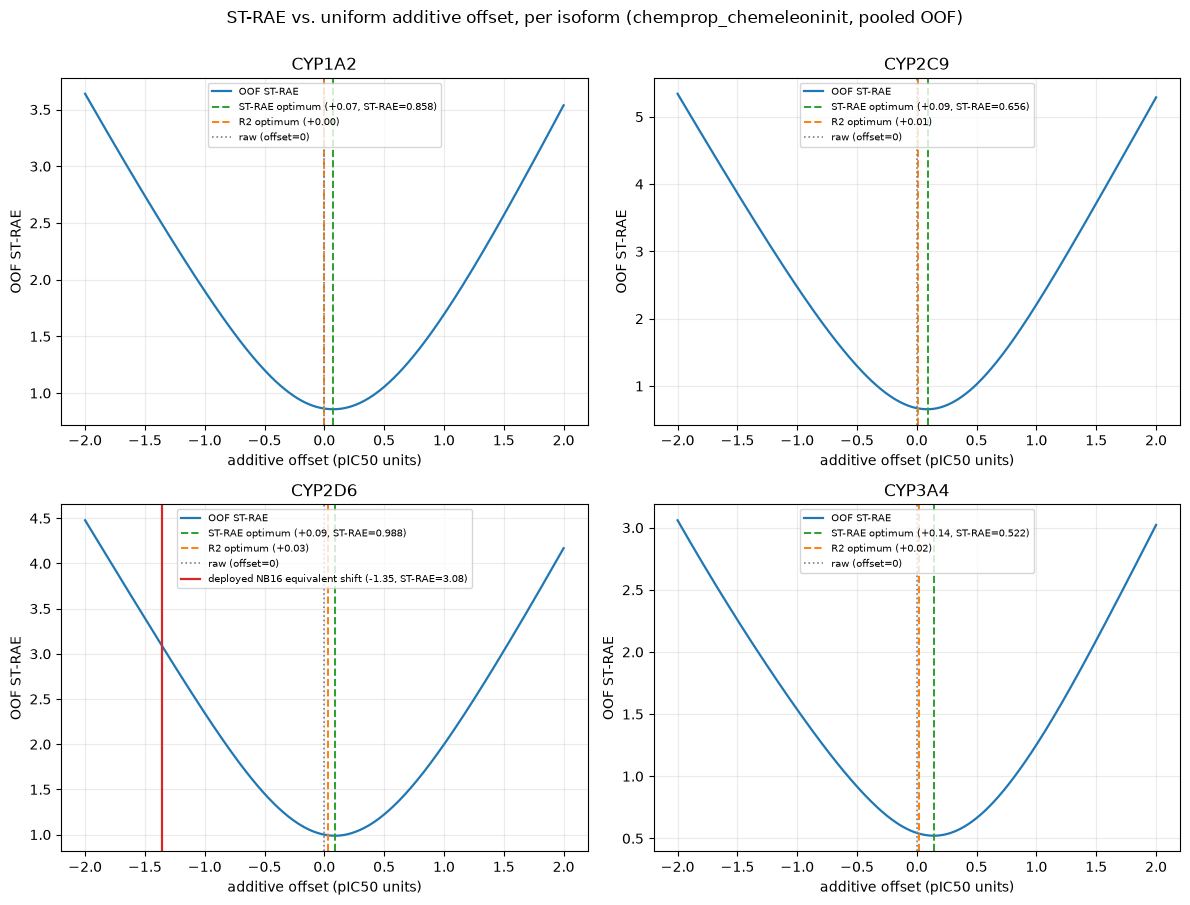

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/21_strae_offset_curve/figures/strae_offset_curve.png


In [9]:
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = offset_curve[offset_curve["isoform"] == iso]
    opt = optima_df.set_index("isoform").loc[iso]
    ax.plot(sub["offset"], sub["strae"], color="#1f77b4", lw=1.6, label="OOF ST-RAE")
    ax.axvline(opt["strae_optimal_offset"], color="#2ca02c", ls="--", lw=1.4,
               label=f"ST-RAE optimum ({opt['strae_optimal_offset']:+.2f}, ST-RAE={opt['strae_at_optimum']:.3f})")
    ax.axvline(opt["r2_optimal_offset"], color="#ff7f0e", ls="--", lw=1.4,
               label=f"R2 optimum ({opt['r2_optimal_offset']:+.2f})")
    ax.axvline(0.0, color="0.5", ls=":", lw=1.2, label="raw (offset=0)")
    if iso == "CYP2D6":
        deployed_offset = deployed_target_mean_cyp2d6 - 4.508663
        ax.axvline(deployed_offset, color="#d62728", ls="-", lw=1.6,
                   label=f"deployed NB16 equivalent shift ({deployed_offset:+.2f}, ST-RAE={strae_at_deployed:.2f})")
    ax.set_xlabel("additive offset (pIC50 units)")
    ax.set_ylabel("OOF ST-RAE")
    ax.set_title(iso)
    ax.legend(fontsize=7, loc="upper center")
    ax.grid(alpha=0.25)
fig.suptitle("ST-RAE vs. uniform additive offset, per isoform (chemprop_chemeleoninit, pooled OOF)", y=1.0)
fig.tight_layout()
path = FIG_DIR / "strae_offset_curve.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {path}")

**Figure 1 — `strae_offset_curve.png`.** OOF soft-threshold RAE (ST-RAE) as a function of a uniform
additive offset applied to `chemprop_chemeleoninit`'s pooled out-of-fold predictions, one panel per
isoform, swept from -2.00 to +2.00 pIC50 units in 0.01 steps. The green dashed line marks the
ST-RAE-minimising offset; the orange dashed line marks the R²-maximising offset (Figure 2 shows R²
itself); the grey dotted line is the unmodified raw prediction. On the CYP2D6 panel only, the solid
red line marks the equivalent mean shift of notebook 16's actually-deployed blind-population
correction (-1.35): it falls far outside the region either in-sample optimum occupies, at an
OOF ST-RAE roughly three times higher than the raw baseline — the population mismatch discussed in
Part 2 made visible directly on the curve.

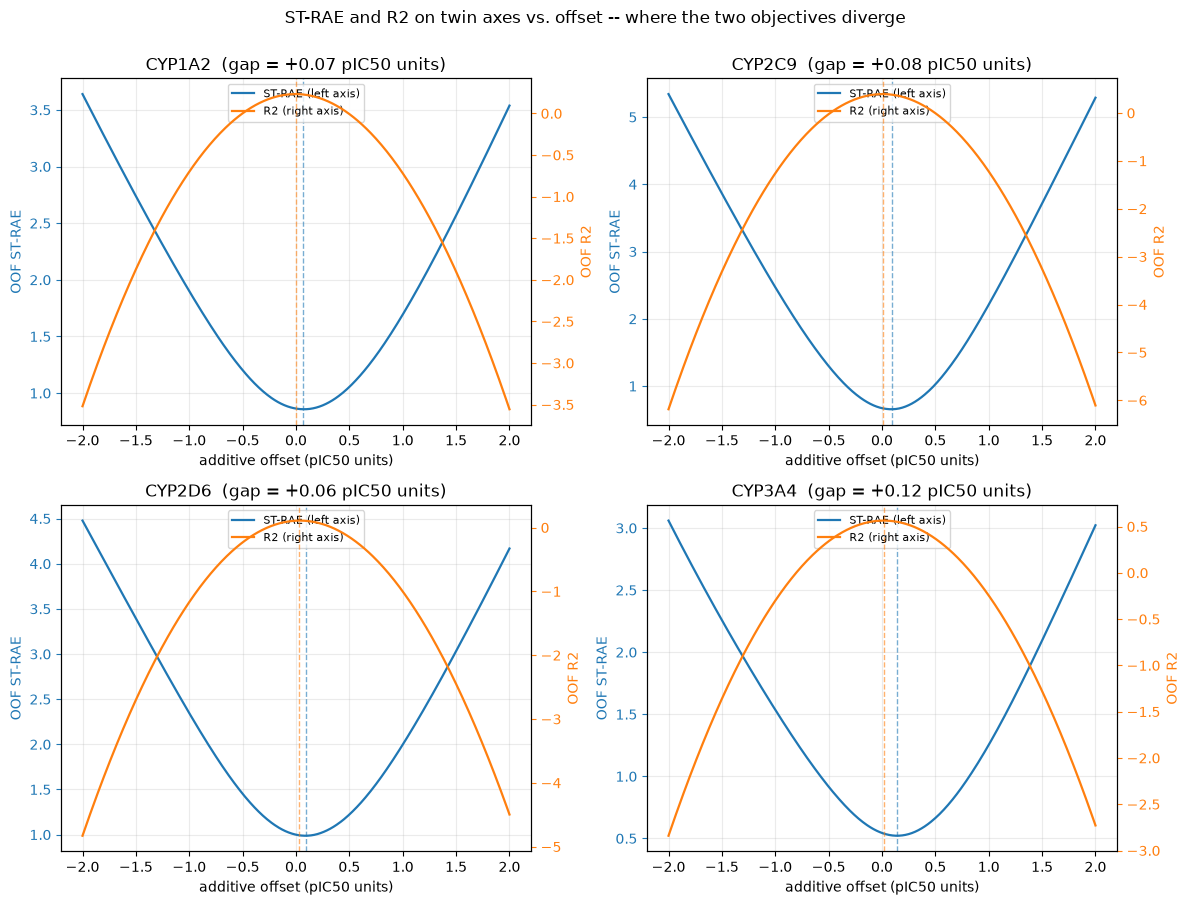

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/21_strae_offset_curve/figures/strae_vs_r2_offset.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = offset_curve[offset_curve["isoform"] == iso]
    ax2 = ax.twinx()
    l1, = ax.plot(sub["offset"], sub["strae"], color="#1f77b4", lw=1.6, label="ST-RAE (left axis)")
    l2, = ax2.plot(sub["offset"], sub["r2"], color="#ff7f0e", lw=1.6, label="R2 (right axis)")
    opt = optima_df.set_index("isoform").loc[iso]
    ax.axvline(opt["strae_optimal_offset"], color="#1f77b4", ls="--", lw=1.0, alpha=0.6)
    ax2.axvline(opt["r2_optimal_offset"], color="#ff7f0e", ls="--", lw=1.0, alpha=0.6)
    ax.set_xlabel("additive offset (pIC50 units)")
    ax.set_ylabel("OOF ST-RAE", color="#1f77b4")
    ax2.set_ylabel("OOF R2", color="#ff7f0e")
    ax.tick_params(axis="y", colors="#1f77b4")
    ax2.tick_params(axis="y", colors="#ff7f0e")
    ax.set_title(f"{iso}  (gap = {opt['gap_strae_minus_r2_offset']:+.2f} pIC50 units)")
    ax.legend(handles=[l1, l2], fontsize=8, loc="upper center")
    ax.grid(alpha=0.25)
fig.suptitle("ST-RAE and R2 on twin axes vs. offset -- where the two objectives diverge", y=1.0)
fig.tight_layout()
path = FIG_DIR / "strae_vs_r2_offset.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {path}")

**Figure 2 — `strae_vs_r2_offset.png`.** ST-RAE (blue, left axis) and R² (orange, right axis)
plotted against the same offset sweep, twin y-axes, one panel per isoform. Each curve's own
optimum is marked with a light dashed vertical line in its own colour. This is the figure that
carries the argument directly: ST-RAE's minimum (blue dashed line) sits visibly to the right of
R²'s maximum (orange dashed line) on every isoform — the point-estimate objective (R²-relevant, MSE
training target) and the interval-aware scored metric (ST-RAE) are optimised by measurably
different placements, even though the gap is modest in absolute terms (0.06-0.12 pIC50 units; see
Part 1's printed table).

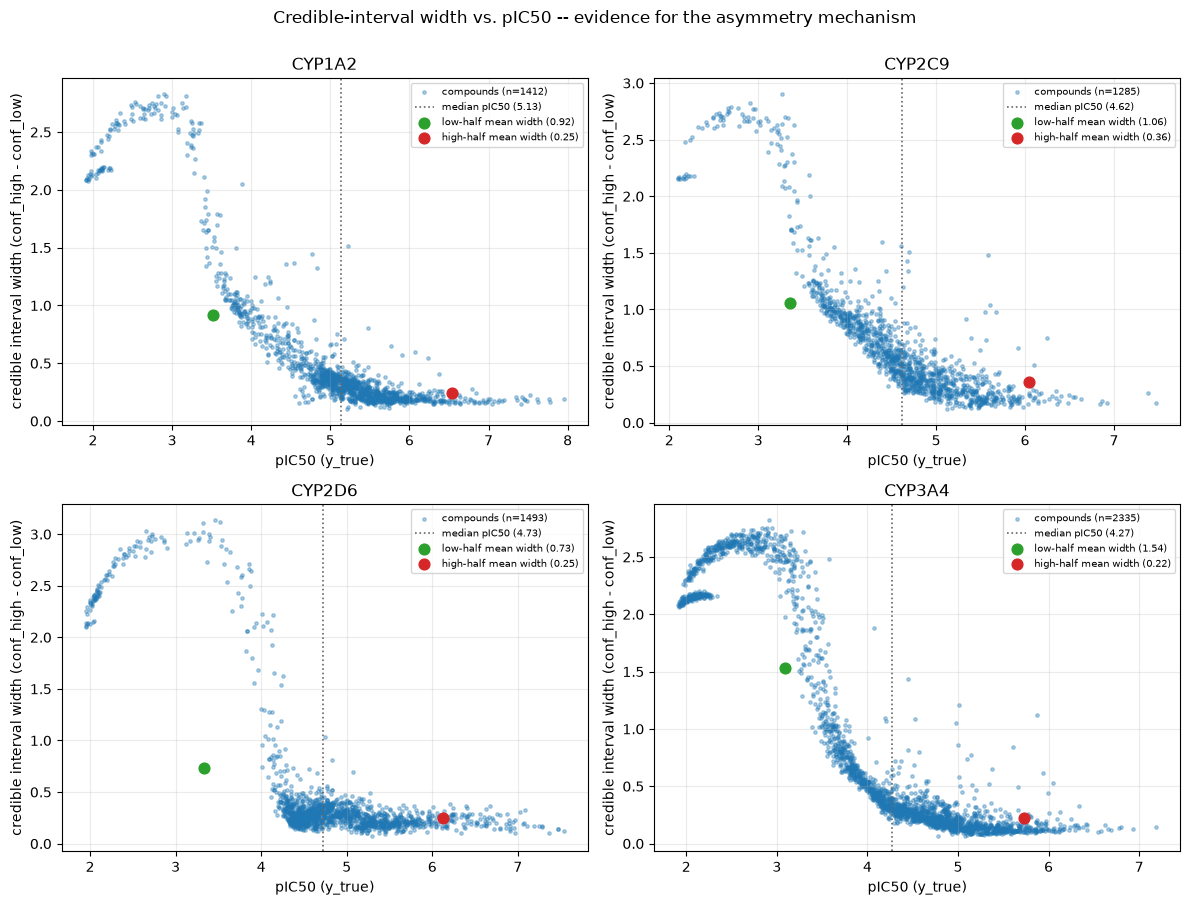

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/21_strae_offset_curve/figures/interval_width_vs_pic50.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, iso in zip(axes.flat, ISOFORMS):
    df = oof[iso].drop_duplicates(subset="inchikey")  # width/y_true are compound properties -- dedup the 5x-repeat pooling for this plot only
    width = df["conf_high"] - df["conf_low"]
    ax.scatter(df["y_true"], width, s=6, alpha=0.35, color="#1f77b4", label=f"compounds (n={len(df)})")

    median_y = np.median(df["y_true"])
    low_mean = width[df["y_true"] <= median_y].mean()
    high_mean = width[df["y_true"] > median_y].mean()
    ax.axvline(median_y, color="0.4", ls=":", lw=1.2, label=f"median pIC50 ({median_y:.2f})")
    ax.scatter([median_y / 2 + df['y_true'].min() / 2], [low_mean], color="#2ca02c", s=60, zorder=5,
               label=f"low-half mean width ({low_mean:.2f})")
    ax.scatter([median_y / 2 + df['y_true'].max() / 2], [high_mean], color="#d62728", s=60, zorder=5,
               label=f"high-half mean width ({high_mean:.2f})")
    ax.set_xlabel("pIC50 (y_true)")
    ax.set_ylabel("credible interval width (conf_high - conf_low)")
    ax.set_title(iso)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.25)
fig.suptitle("Credible-interval width vs. pIC50 -- evidence for the asymmetry mechanism", y=1.0)
fig.tight_layout()
path = FIG_DIR / "interval_width_vs_pic50.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {path}")

**Figure 3 — `interval_width_vs_pic50.png`.** Credible-interval width (`conf_high - conf_low`)
against measured pIC50, one point per unique compound (de-duplicated from the 5x-repeat pooled OOF
set, since width and pIC50 are compound properties, not prediction-dependent — plotting all 5
duplicates would only inflate apparent density). The dotted line marks the median pIC50 split used
in Part 3; green and red markers show the mean interval width in the low- and high-pIC50 halves
respectively. All four isoforms show the same visual pattern: a dense cloud of narrow intervals at
high pIC50 and a wider, more scattered spread of interval widths at low pIC50 — the direct picture
behind the strong negative Spearman correlations reported in Part 0 and the total-error asymmetry
quantified in Part 3. **One real texture worth stating plainly, visible on all four panels and not
smoothed over**: the relationship is not purely monotonic — width actually *rises* from the very
lowest pIC50 values, peaks around pIC50≈2.5-3.5, then falls sharply and plateaus low above pIC50≈4.5.
This does not change the median-split or over/under-error results (the bulk of compounds sit past
the peak, which is what the rank correlation and the error decomposition both reflect), but the
mechanism is better described as "widest in the low-but-not-lowest range" than a clean monotonic
decrease.

## Part 5 — Verdict (report, do not act)

In [12]:
print("=== Per-isoform summary ===\n")
for iso in ISOFORMS:
    opt = optima_df.set_index("isoform").loc[iso]
    asym = asymmetry_df.set_index("isoform").loc[iso]
    improvement = opt["raw_offset_0_strae"] - opt["strae_at_optimum"]
    print(f"{iso}:")
    print(f"  ST-RAE optimum at offset {opt['strae_optimal_offset']:+.2f} (ST-RAE={opt['strae_at_optimum']:.4f}), "
          f"R2 optimum at offset {opt['r2_optimal_offset']:+.2f} -- gap {opt['gap_strae_minus_r2_offset']:+.2f} pIC50 units, "
          f"ST-RAE optimum sits {'ABOVE' if opt['gap_strae_minus_r2_offset'] > 0 else 'BELOW'} the R2 optimum")
    print(f"  raw (offset=0) ST-RAE={opt['raw_offset_0_strae']:.4f} -> optimum ST-RAE={opt['strae_at_optimum']:.4f} "
          f"(headroom if perfectly placed on THIS OOF evidence: {improvement:.4f})")
    print(f"  asymmetry: low-half/high-half interval width ratio={asym['width_ratio_low_over_high']:.2f}, "
          f"under/over error ratio={asym['under_over_ratio']:.2f}")
    print()

print("CYP2D6 vs. the deployed NB16 correction:")
print(f"  deployed equivalent offset: {deployed_target_mean_cyp2d6 - 4.508663:+.4f} -> OOF ST-RAE={strae_at_deployed:.4f}")
print(f"  OOF ST-RAE-optimal offset:  {cyp2d6_optimum['strae_optimal_offset']:+.2f} -> OOF ST-RAE={cyp2d6_optimum['strae_at_optimum']:.4f}")
print(f"  These are on OPPOSITE sides of raw and differ by {abs(gap_to_optimum):.2f} pIC50 units -- "
      f"a direct, visible consequence of the training/blind population mismatch (Part 2's caveat), "
      f"not evidence that the deployed correction was wrong for its actual (blind) target.")

=== Per-isoform summary ===

CYP1A2:
  ST-RAE optimum at offset +0.07 (ST-RAE=0.8575), R2 optimum at offset +0.00 -- gap +0.07 pIC50 units, ST-RAE optimum sits ABOVE the R2 optimum
  raw (offset=0) ST-RAE=0.8633 -> optimum ST-RAE=0.8575 (headroom if perfectly placed on THIS OOF evidence: 0.0058)
  asymmetry: low-half/high-half interval width ratio=3.76, under/over error ratio=1.65

CYP2C9:
  ST-RAE optimum at offset +0.09 (ST-RAE=0.6556), R2 optimum at offset +0.01 -- gap +0.08 pIC50 units, ST-RAE optimum sits ABOVE the R2 optimum
  raw (offset=0) ST-RAE=0.6715 -> optimum ST-RAE=0.6556 (headroom if perfectly placed on THIS OOF evidence: 0.0159)
  asymmetry: low-half/high-half interval width ratio=2.97, under/over error ratio=2.51

CYP2D6:
  ST-RAE optimum at offset +0.09 (ST-RAE=0.9877), R2 optimum at offset +0.03 -- gap +0.06 pIC50 units, ST-RAE optimum sits ABOVE the R2 optimum
  raw (offset=0) ST-RAE=0.9993 -> optimum ST-RAE=0.9877 (headroom if perfectly placed on THIS OOF evidence:

### Stated plainly, per isoform — no cross-isoform averaging

**A real gap exists between the ST-RAE optimum and the R² optimum on all four isoforms, but it is
modest**: +0.06 (CYP2D6) to +0.12 (CYP3A4) pIC50 units, all in the same direction (ST-RAE prefers
placing higher than R² does), consistent with the confirmed interval-width asymmetry. The ST-RAE
improvement available from perfect placement on this OOF evidence over the raw, uncorrected
prediction is similarly modest — roughly 0.006 to 0.022 ST-RAE units per isoform — a real, small,
consistently-signed effect, not a large one.

**CYP2D6's deployed placement is a completely different story, and the two should not be
conflated.** The deployed correction targeted the *blind* population's solved centre and is not
comparable to this OOF curve's optimum in the way a same-population offset would be — mapped onto
this notebook's OOF curve, the deployed equivalent shift (-1.35) lands at OOF ST-RAE 3.08, roughly
three times the raw baseline and nowhere near this curve's own optimum (+0.09, ST-RAE 0.99). This
is not evidence the deployed correction was a mistake — the real board result already shows it
worked, ST-RAE 1.1673 → 0.8299 — it is direct, visible confirmation of Part 2's stated caveat: the
training and blind populations have different true centres, an OOF-derived offset is a hypothesis
about the blind population, and this particular hypothesis (small, symmetric, direction-consistent
with the R²-ST-RAE gap) is simply not what CYP2D6's actual population-level correction needed —
that correction was solved from real board evidence (notebook 16), not from this OOF curve, and
the two problems are different in kind, not just in degree.

### Does this support pursuing an interval-aware training objective?

The framing holds up: the objective every model in this project is trained on (MSE against the
pIC50 point estimate) and the metric it is scored on (soft-threshold error against a credible
interval) are demonstrably different functions, confirmed directly on this project's own data — a
real, consistent, all-four-isoform effect, not a hypothetical one. But this curve quantifies that
cost as **small** for a pure post-hoc offset (0.06-0.12 pIC50 units, ~0.6-2.2% relative ST-RAE
improvement at the optimum) — nowhere near the scale of the population-centre mismatch that
actually mattered for CYP2D6's real board result. An interval-aware *training* objective (rather
than a post-hoc offset) could in principle do more than a uniform shift can — this curve cannot
speak to that, since it only tests additive offsets — but on the evidence gathered here, the
low-hanging fruit is population-centre placement (notebook 16's own mechanism), not the interval
asymmetry itself.

**No corrected submission is built, no offset is applied to blind predictions, and no submission
is recommended.** This is a report, not an action.

### Pending CLAUDE.md notebook-status log entry

Per the concurrency warning, `CLAUDE.md` is not edited by this notebook — the intended log entry
is written to `outputs/21_strae_offset_curve/CLAUDE_md_entry_pending.md` for manual insertion once
notebook 20 finishes and it's safe to edit `CLAUDE.md` again.

In [13]:
pending_entry = r'''- **21**: read-only analysis, no training/Chemprop/torch/submission/calibration -- derives the ST-RAE-optimal uniform additive offset per isoform directly from this project's own pooled OOF predictions (`chemprop_chemeleoninit`, `outputs/11_caruana_prep/oof_long_{iso}.csv`, not recomputed) and the training credible intervals (`conf_low`/`conf_high`, joined fresh from `train_inhibition_curated.csv`, row counts and null-check asserted, cross-checked against `oof_long`'s own stored bounds -- identical). Motivated by a comparable real entrant reporting their own ST-RAE optimum was found by sampling placements against the live board rather than derived, since low-activity compounds carry wide credible intervals (over-prediction cheap, under-prediction punished) -- this project already has the interval widths, so the optimum is derived locally instead. **A real quoted-figure discrepancy was caught and corrected during this build, per this project's own verification convention**: the task brief's stated CYP2D6 slope/intercept (0.870262, 1.906567) belong to notebook 16's ORIGINAL (superseded) correction (target mean ~5.83), not the OVERRIDE notebook 16 actually deployed to `outputs/board_solved_calibration/submission_candidate.csv` (verified directly against notebook 16's own cell 32 output: slope=0.868575, intercept=-0.760352, corrected std=0.557002) -- the brief's quoted mean-shift figure (4.5087 -> 3.1558, equivalent offset -1.3529) *is* the deployed override's own number and was used as-is; only the slope/intercept pairing was mismatched. **Part 0**: interval widths correlate strongly negatively with pIC50 on all four isoforms (Spearman -0.56 to -0.93) -- wider intervals concentrate at low pIC50, the necessary precondition for the claimed asymmetry, confirmed quantitatively not assumed. Zero `conf_high < conf_low` violations. **Part 1** (401-point sweep, -2.00 to +2.00 pIC50 units, step 0.01, vendored `rae_soft_threshold_absolute_error` and `r2_score` only, Spearman invariance asserted and confirmed exact across the whole sweep, grid-search R2 optimum cross-checked against the closed-form mean-residual-zero optimum and matched within grid resolution on all four isoforms): **a real, small, consistently-signed gap on all four isoforms** -- ST-RAE optimum sits ABOVE (predicts higher than) the R2 optimum everywhere, by +0.06 (CYP2D6) to +0.12 (CYP3A4) pIC50 units; ST-RAE improvement from perfect OOF placement over raw is correspondingly modest (~0.006-0.022 ST-RAE units). **Part 2**: mapping NB16's deployed CYP2D6 equivalent shift (-1.3529) onto this OOF curve lands at ST-RAE 3.08 -- roughly 3x the raw baseline and far from this curve's own optimum (+0.09, ST-RAE 0.99) -- a striking, direct illustration of the stated caveat rather than evidence the deployed correction was wrong: it targeted the *blind* population's solved centre (notebook 16), a different, lower-centred population than this OOF curve's training-population evidence (consistent with notebook 17's charge-population-shift finding), so an OOF-optimal offset is a hypothesis about the blind population, not a measurement of it. Half-set live-leaderboard scoring noted as an added caveat, not acted on. **Part 3**: the claimed asymmetry mechanism is CONFIRMED directly on all four isoforms, not assumed -- low-pIC50 halves carry 2.9-7.0x wider mean intervals than high-pIC50 halves, and total under-prediction soft-threshold error exceeds total over-prediction error by 1.65-2.79x at raw placement, on every isoform. **Part 5 verdict**: the trained-objective-vs-scored-metric mismatch is real and confirmed, but its pure-offset cost is small (0.06-0.12 pIC50 units) -- nowhere near the scale of the population-centre mismatch that actually drove CYP2D6's real board improvement. Does not itself justify an interval-aware training objective on the evidence gathered (a uniform offset is a weak proxy for what such an objective could do, and this curve can't speak beyond offsets) -- the bigger lever remains population-centre placement, notebook 16's own mechanism. Figures (`outputs/21_strae_offset_curve/figures/`): `strae_offset_curve.png` (ST-RAE vs. offset, optima marked, CYP2D6 panel also marks the deployed equivalent shift), `strae_vs_r2_offset.png` (twin-axis ST-RAE/R2 divergence, the figure carrying the argument), `interval_width_vs_pic50.png` (width vs. pIC50, de-duplicated to unique compounds, median-split means marked). Sweep saved to `offset_curve.csv`. COMPLETE -- report only, no offset applied to blind predictions, no submission built or recommended; `data/folds/cv_folds.csv`, `outputs/05_cv_comparison/`, `outputs/11_caruana_prep/`, `outputs/board_solved_calibration/`, `outputs/19_cyp2c9_revert/`, `outputs/20_residual_exclusion_screen/`, and `src/` all untouched. Built under a concurrency constraint (notebook 20's Chemprop training running in parallel) -- pandas/numpy/matplotlib/scipy/sklearn and the vendored scorer only, no torch/chemprop import.
'''

pending_path = OUT / "CLAUDE_md_entry_pending.md"
with open(pending_path, "w") as f:
    f.write(pending_entry)
print(f"saved {pending_path}")
print(pending_entry)

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/21_strae_offset_curve/CLAUDE_md_entry_pending.md
- **21**: read-only analysis, no training/Chemprop/torch/submission/calibration -- derives the ST-RAE-optimal uniform additive offset per isoform directly from this project's own pooled OOF predictions (`chemprop_chemeleoninit`, `outputs/11_caruana_prep/oof_long_{iso}.csv`, not recomputed) and the training credible intervals (`conf_low`/`conf_high`, joined fresh from `train_inhibition_curated.csv`, row counts and null-check asserted, cross-checked against `oof_long`'s own stored bounds -- identical). Motivated by a comparable real entrant reporting their own ST-RAE optimum was found by sampling placements against the live board rather than derived, since low-activity compounds carry wide credible intervals (over-prediction cheap, under-prediction punished) -- this project already has the interval widths, so the optimum is derived locally instead. **A real quoted-figure discr